In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


In [2]:
import os
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

In [7]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
sample = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

In [8]:
train.shape

(2000, 8)

In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


In [10]:
train.isnull().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

In [11]:
train.duplicated().sum()

np.int64(0)

In [15]:
#Class Distribution
train["answer"].value_counts()

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

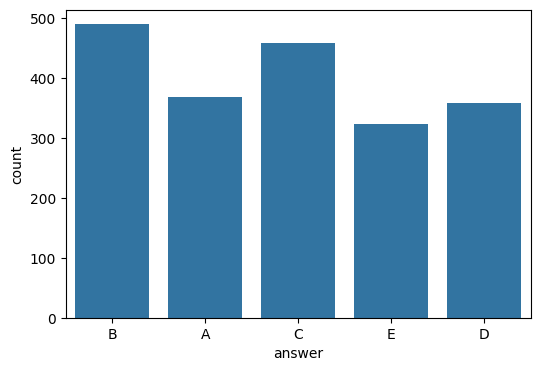

In [16]:
#class distribution plot
plt.figure(figsize=(6,4))

sns.countplot(x="answer",data=train)

plt.show()

In [18]:
#prompt length
train["prompt_length"] = train["prompt"].apply(len)

In [19]:
train["prompt_length"].describe()

count    2000.000000
mean      117.669500
std        44.408674
min        19.000000
25%        87.750000
50%       111.000000
75%       141.000000
max       337.000000
Name: prompt_length, dtype: float64

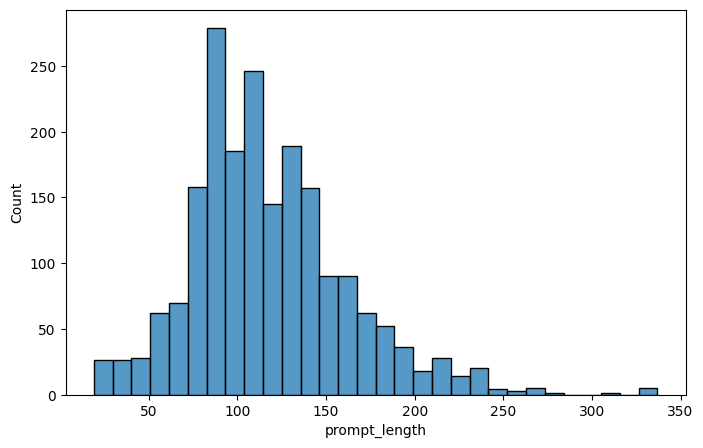

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(train["prompt_length"],bins=30)

plt.show()

In [21]:
train.iloc[0]

id                                                               1
prompt           Pick the best possible answer: What is Martin ...
A                Martin Heidegger believes that humans exist wi...
B                Martin Heidegger believes that humans do not e...
C                Martin Heidegger does not believe in the exist...
D                Martin Heidegger believes that the relationshi...
E                Martin Heidegger believes that time is an illu...
answer                                                           B
prompt_length                                                  142
Name: 0, dtype: object

In [22]:
# Calculate length of each option

for col in ["A", "B", "C", "D", "E"]:
    train[f"{col}_length"] = train[col].astype(str).apply(len)

In [23]:
option_length_stats = train[
    ["A_length", "B_length", "C_length", "D_length", "E_length"]
].describe()

display(option_length_stats)

,A_length,B_length,C_length,D_length,E_length
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,164.091500,166.616500,167.227000,162.56350,164.230000
std,105.677145,113.829917,105.723674,104.11657,107.777712
min,1.000000,2.000000,2.000000,1.00000,2.000000
25%,86.000000,82.000000,88.000000,91.00000,84.000000
50%,143.000000,151.000000,158.000000,141.00000,144.000000
75%,234.000000,222.000000,224.000000,231.00000,224.000000
max,472.000000,662.000000,530.000000,450.00000,587.000000


In [24]:
#Class Percentages
answer_percentage = (
    train["answer"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

display(answer_percentage)

answer
A    18.45
B    24.50
C    22.95
D    17.90
E    16.20
Name: proportion, dtype: float64

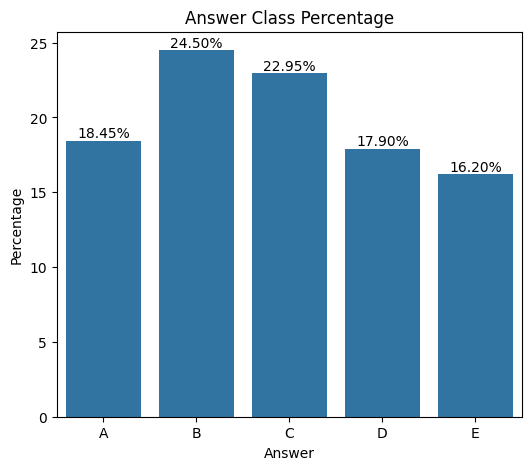

In [25]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    x=answer_percentage.index,
    y=answer_percentage.values
)

plt.title("Answer Class Percentage")
plt.xlabel("Answer")
plt.ylabel("Percentage")

for i, value in enumerate(answer_percentage.values):
    ax.text(i, value+0.2, f"{value:.2f}%", ha="center")

plt.show()

## EDA Observations

- Dataset contains approximately 2000 training samples and 500 test samples.
- No missing values or duplicate rows were observed.
- The answer classes (A–E) are nearly balanced, reducing the risk of class bias.
- Prompt lengths vary but most questions fall within a moderate character range.
- Option lengths are fairly consistent across all five choices, suggesting no significant length-based bias.
- The dataset appears clean and suitable for training without extensive preprocessing.